In [52]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sc_toolbox as sct

In [2]:
mpl.rcParams["figure.figsize"] = (5, 5)

In [3]:
plt.rcParams['pdf.fonttype'] = 42

In [4]:
adata = sc.read('../data/cellcharter_dmg_FINAL.h5ad')
adata

AnnData object with n_obs × n_vars = 26552 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample', 'sample2', 'orig.ident', 'nCount_Nanostring', 'nFeature_Nanostring', 'Mean.rRNA_CD298_B2M', 'Max.rRNA_CD298_B2M', 'Slide_name', 'Run_name', 'ISH.concentration', 'Beta', 'tissue', 'Run_Slide_name', 'slide_ID_numeric', 'Run_Tissue_name', 'log10totalcounts', 'IFcolor', 'nb_clus', 'leiden_clus', 'id', 'FOV', 'PMCID', 'Replicate', 'ID_R', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tangram_prediction', 'leiden', 'cellcharter_6', 'cellcharter_9', 'cellcharter_12'
    var: 'n_counts'
    uns: 'PMCID_colors', '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'spatial

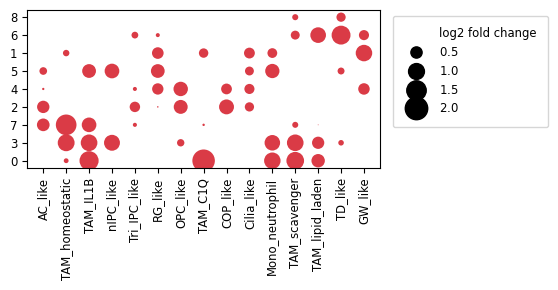

In [11]:
cc.pl.enrichment(
    adata,
    group_key='cellcharter_9',
    label_key='tangram_prediction',
    # cluster_labels=False,
    figsize=(4, 3),
    labels=['AC_like','TAM_homeostatic','TAM_IL1B',
            'nIPC_like','Tri_IPC_like',
            'RG_like','OPC_like','TAM_C1Q',
            'COP_like','Cilia_like',
            'Mono_neutrophil','TAM_scavenger',
            'TAM_lipid_laden','TD_like','GW_like']
    # size_threshold=1,
    # color_threshold=0.5,
    # save='figures/enrichment_cellcharter_celltype_vs_niche.pdf'
)

In [ ]:
celltypes_to_keep = ['RG_like', 'Tri_IPC_like','nIPC_like','OPC_like',
                     'COP_like','AC_like','Cilia_like','TD_like','GW_like',
                     'Mono_neutrophil',
                     'TAM_C1Q','TAM_lipid_laden','TAM_scavenger','TAM_IL1B','TAM_homeostatic']

subset_adata = adata[adata.obs['tangram_prediction'].isin(celltypes_to_keep)].copy()
subset_adata

In [13]:
signatures = pd.read_excel('../data/tumor_cell_state_signatures_gavish.xlsx')
signatures.columns = [c.replace('/', '').replace('  ', '_').replace(' - ', '-').replace(' ', '_') for c in signatures.columns]
signatures_dict = signatures.to_dict(orient='list')

In [23]:
hypoxia_MP6 = ['VEGFA', 'HILPDA', 'SLC6A6', 'FAM162A', 'NDRG1', 'PDK1', 'INSIG2', 'SLC2A1', 'GBE1', 'AKAP12', 'ERO1A', 'HK2', 'PGK1', 'PLOD2', 'PFKFB4', 'BNIP3L', 'EGLN3', 'BNIP3', 'PFKP', 'PRELID2', 'IGFBP5', 'AK4', 'SORCS3', 'ADM', 'PCBP3', 'SLC2A3', 'CDON', 'DNAH11', 'EPAS1', 'KDM3A', 'ENO1', 'ITPR1', 'TMEM45A', 'DDIT4', 'EGLN1', 'GAPDH', 'P4HA1', 'PPFIA4', 'PRKCB', 'ADCY8', 'C4ORF47', 'CA12', 'CLEC2B', 'ENO2', 'FAM210A', 'IGFBP2', 'NGLY1', 'CDK19', 'CA9', 'ZNF395']

stress_MP10 = ['HSPH1', 'HSPE1', 'USPL1', 'CHORDC1', 'HSPD1', 'DNAJB1', 'HSP90AA1', 'HSP90AB1', 'HSPA1A', 'HSPA1B', 'HSPA6', 'CACYBP', 'DNAJB6', 'HSPA4', 'HSPB1', 'ACSL3', 'SERPINH1', 'AHSA1', 'HSPA8', 'TCP1', 'ZFAND2A', 'BAG3', 'CRYAB', 'DNAJB4', 'HES1', 'HSPA4L', 'HSPA9', 'RRAD', 'STIP1', 'UBB', 'UBC', 'ATP2C1', 'DNAJA1', 'DNAJA4', 'ID2', 'MOB4', 'NFKBIA', 'OSBPL3', 'PTGES3', 'SLC38A2', 'PLCG2', 'PLOD2', 'GEM', 'TENT4B', 'C11ORF96', 'TAF7', 'OAZ1', 'ADM', 'CD83', 'TNFAIP3']

In [28]:
invasivity = [
    'AC114730.3', 'ACAT2', 'ACTB', 'ANAPC11', 'ANXA2', 'AP2S1', 'ASCL1', 'ASPM', 'ATF3', 'ATP1B3',
    'AURKA', 'AURKAIP1', 'AURKB', 'B2M', 'BCAN', 'BCL7C', 'BIRC5', 'BTG1', 'BUB1', 'BUD31', 'CALM1',
    'CALM2', 'CASC5', 'CCDC109B', 'CCNA2', 'CDCA3', 'CDK1', 'CDKN3', 'CENPA', 'CENPF', 'CENPK',
    'CFL1', 'CHCHD2', 'CHCHD3', 'CKAP2', 'CKS1B', 'CLIC1', 'CLU', 'CNN3', 'COPRS', 'COX5A', 'COX8A',
    'CRYAB', 'CTNNAL1', 'CYR61', 'DCX', 'DLGAP5', 'DLL1', 'DLL3', 'DNAJB1', 'DNPH1', 'DTYMK', 'ECI1',
    'EEF1B2', 'ETFB', 'ETV1', 'FAM64A', 'FAM83D', 'FBXO5', 'FDPS', 'FIBP', 'GAPDH', 'GFAP', 'GNB2',
    'GPX4', 'GSTP1', 'GTSE1', 'H2AFZ', 'HES6', 'HINT1', 'HINT2', 'HIST1H4C', 'HJURP', 'HMGB2', 'HOPX',
    'ITGB1BP1', 'KCNQ1OT1', 'KIAA0101', 'KIF20A', 'KIF23', 'KIF2C', 'KIFC1', 'KPNA2', 'LINC00152',
    'LMNB1', 'LRRN1', 'LSMD1', 'MAD2L1', 'MALAT1', 'MANF', 'MARCKSL1', 'MEA1', 'MFNG', 'MIR4435-1HG',
    'MKI67', 'MRPL37', 'MT-ND3', 'MT2A', 'MXD3', 'MYC', 'MZT2B', 'NCAPG', 'NDC80', 'NDUFA4', 'NDUFA6',
    'NDUFS8', 'NEK2', 'NEU4', 'NGFRAP1', 'NMB', 'NUF2', 'NUSAP1', 'OLIG1', 'PBK', 'PCOLCE', 'PFN1',
    'PHF19', 'PHPT1', 'PKM', 'POLR2I', 'PPIA', 'PRC1', 'PRR24', 'PSMA7', 'PSMB3', 'PSME2', 'PTN',
    'PTTG1', 'PXMP2', 'RACGAP1', 'RBX1', 'RDX', 'RRM2', 'SGOL1', 'SGOL2', 'SHD', 'SHMT2', 'SIVA1',
    'SLC25A5', 'SMC4', 'SOCS3', 'SOX4', 'SPARC', 'SPC25', 'SSBP4', 'STK17A', 'TAGLN2', 'TCF12',
    'TCTEX1D2', 'TECR', 'TK1', 'TMEM147', 'TMEM54', 'TNFRSF12A', 'TNK2', 'TOP2A', 'TPI1', 'TPX2',
    'TUBA1B', 'TUBA1C', 'TUBB2A', 'TUBB6', 'UBE2C', 'UBE2T', 'UQCC2', 'UQCR10', 'UQCRC1', 'UQCRQ',
    'VIM', 'VMP1', 'ZFP36', 'ZWINT'
]

In [29]:
sc.tl.score_genes(subset_adata, gene_list=invasivity, score_name='invasivity')

       'ATP1B3', 'AURKA', 'AURKAIP1',
       ...
       'TUBA1C', 'TUBB2A', 'TUBB6', 'UBE2T', 'UQCC2', 'UQCR10', 'UQCRC1',
       'UQCRQ', 'VMP1', 'ZWINT'],
      dtype='object', length=140)


In [31]:
niches_to_keep = [7,3,2,5,4,1,6]

subset_adata = adata[adata.obs['cellcharter_9'].isin(niches_to_keep)].copy()
subset_adata

AnnData object with n_obs × n_vars = 22047 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample', 'sample2', 'orig.ident', 'nCount_Nanostring', 'nFeature_Nanostring', 'Mean.rRNA_CD298_B2M', 'Max.rRNA_CD298_B2M', 'Slide_name', 'Run_name', 'ISH.concentration', 'Beta', 'tissue', 'Run_Slide_name', 'slide_ID_numeric', 'Run_Tissue_name', 'log10totalcounts', 'IFcolor', 'nb_clus', 'leiden_clus', 'id', 'FOV', 'PMCID', 'Replicate', 'ID_R', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tangram_prediction', 'leiden', 'cellcharter_6', 'cellcharter_9', 'cellcharter_12'
    var: 'n_counts'
    uns: 'PMCID_colors', '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'spatial

In [32]:
sc.tl.score_genes(subset_adata, gene_list=invasivity, score_name='invasivity')

       'ATP1B3', 'AURKA', 'AURKAIP1',
       ...
       'TUBA1C', 'TUBB2A', 'TUBB6', 'UBE2T', 'UQCC2', 'UQCR10', 'UQCRC1',
       'UQCRQ', 'VMP1', 'ZWINT'],
      dtype='object', length=140)


In [33]:
sc.tl.score_genes(subset_adata, gene_list=hypoxia_MP6+stress_MP10, score_name='hypoxia+stress')

       'PGK1', 'PLOD2', 'PFKFB4', 'BNIP3L', 'BNIP3', 'PFKP', 'PRELID2', 'AK4',
       'SORCS3', 'ADM', 'PCBP3', 'SLC2A3', 'CDON', 'DNAH11', 'KDM3A', 'ENO1',
       'ITPR1', 'TMEM45A', 'DDIT4', 'EGLN1', 'GAPDH', 'P4HA1', 'PPFIA4',
       'PRKCB', 'ADCY8', 'C4ORF47', 'CA12', 'ENO2', 'FAM210A', 'IGFBP2',
       'NGLY1', 'CDK19', 'CA9', 'ZNF395', 'HSPH1', 'HSPE1', 'USPL1', 'CHORDC1',
       'HSPD1', 'DNAJB1', 'HSPA6', 'CACYBP', 'DNAJB6', 'HSPA4', 'ACSL3',
       'AHSA1', 'HSPA8', 'TCP1', 'ZFAND2A', 'DNAJB4', 'HES1', 'HSPA4L',
       'HSPA9', 'RRAD', 'STIP1', 'UBB', 'UBC', 'ATP2C1', 'DNAJA1', 'DNAJA4',
       'ID2', 'MOB4', 'OSBPL3', 'SLC38A2', 'PLCG2', 'GEM', 'TENT4B',
       'C11ORF96', 'TAF7', 'OAZ1', 'TNFAIP3'],
      dtype='object')


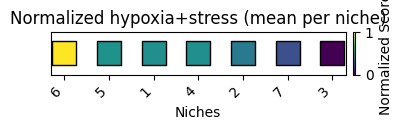

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Prepare data
df = subset_adata.obs[['hypoxia+stress', 'cellcharter_9']].copy()

# Sort by median, as in violin plot
group_medians = df.groupby('cellcharter_9', observed=True)['hypoxia+stress'].median()
sorted_order = group_medians.sort_values(ascending=False).index.tolist()

# Compute normalized means
group_means = df.groupby('cellcharter_9', observed=True)['hypoxia+stress'].mean()
normalized_means = (group_means - group_means.min()) / (group_means.max() - group_means.min())
dot_df = normalized_means.loc[sorted_order].reset_index()
dot_df.columns = ['cellcharter_9', 'normalized_score']

# Create integer x positions for categorical labels
dot_df['x'] = range(len(dot_df))

# Set up colormap
norm = Normalize(vmin=0, vmax=1)
cmap = plt.cm.viridis
colors = cmap(norm(dot_df['normalized_score']))

# Plot
fig, ax = plt.subplots(figsize=(4, 1.4))
ax.scatter(
    x=dot_df['x'],
    y=[0] * len(dot_df),
    c=colors,
    s=300,
    edgecolor='k',
    marker='s'
)

# Format ticks and labels
ax.set_xticks(dot_df['x'])
ax.set_xticklabels(dot_df['cellcharter_9'], rotation=45, ha='right')
ax.set_yticks([])
ax.set_xlabel('Niches')
ax.set_title('Normalized hypoxia+stress (mean per niche)')

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Normalized Score')

plt.tight_layout()
plt.savefig('figures/hypoxia_stress_cellcharter_niches_normalized.pdf')
plt.show()

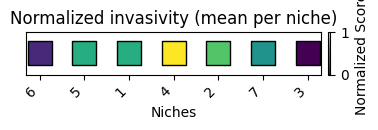

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Define custom order
sorted_order = [6, 5, 1, 4, 2, 7, 3]

# Extract and compute group means
df = subset_adata.obs[['invasivity', 'cellcharter_9']].copy()
group_means = df.groupby('cellcharter_9', observed=True)['invasivity'].mean()

# Normalize mean values between 0 and 1
normalized_means = (group_means - group_means.min()) / (group_means.max() - group_means.min())

# Apply custom sorting
dot_df = normalized_means.loc[sorted_order].reset_index()
dot_df.columns = ['cellcharter_9', 'normalized_score']
dot_df['x'] = range(len(dot_df))  

# Set up colormap
norm = Normalize(vmin=0, vmax=1)
cmap = plt.cm.viridis
colors = cmap(norm(dot_df['normalized_score']))

# Plot
fig, ax = plt.subplots(figsize=(4, 1.4))
ax.scatter(
    x=dot_df['x'],
    y=[0] * len(dot_df),
    c=colors,
    s=300,
    edgecolor='k',
    marker='s'
)

# Format
ax.set_xticks(dot_df['x'])
ax.set_xticklabels(dot_df['cellcharter_9'], rotation=45, ha='right')
ax.set_yticks([])
ax.set_xlabel('Niches')
ax.set_title('Normalized invasivity (mean per niche)')

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Normalized Score')

plt.tight_layout()
plt.savefig('figures/invasivity_cellcharter_niches_normalized.pdf')
plt.show()

In [48]:
signatures = pd.read_excel('../data/tumor_cell_state_signatures_gavish.xlsx')
signatures.columns = [c.replace('/', '').replace('  ', '_').replace(' - ', '-').replace(' ', '_') for c in signatures.columns]
signatures_dict = signatures.to_dict(orient='list')

In [49]:
signatures_dict['Cell_Proliferation'] = [x for x in pd.concat((
        signatures['MP1_Cell_Cycle-G2M'],
        signatures['MP2_Cell_Cycle-G1S'],
        signatures['MP3_Cell_Cylce_HMG-rich'],
        signatures['MP4_Cell_Cylce_Chromatin_']
    ))
               if x in adata.var_names]

In [53]:
sc.tl.score_genes(subset_adata, gene_list=signatures_dict['Cell_Proliferation'], score_name='cell_cycle')

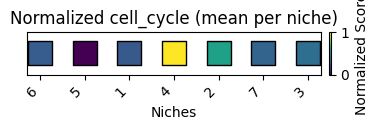

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Define custom order
sorted_order = [6, 5, 1, 4, 2, 7, 3]

# Extract and compute group means
df = subset_adata.obs[['cell_cycle', 'cellcharter_9']].copy()
group_means = df.groupby('cellcharter_9', observed=True)['cell_cycle'].mean()

# Normalize mean values between 0 and 1
normalized_means = (group_means - group_means.min()) / (group_means.max() - group_means.min())

# Apply custom sorting
dot_df = normalized_means.loc[sorted_order].reset_index()
dot_df.columns = ['cellcharter_9', 'normalized_score']
dot_df['x'] = range(len(dot_df))  

# Set up colormap
norm = Normalize(vmin=0, vmax=1)
cmap = plt.cm.viridis
colors = cmap(norm(dot_df['normalized_score']))

# Plot
fig, ax = plt.subplots(figsize=(4, 1.4))
ax.scatter(
    x=dot_df['x'],
    y=[0] * len(dot_df),
    c=colors,
    s=300,
    edgecolor='k',
    marker='s'
)

# Format
ax.set_xticks(dot_df['x'])
ax.set_xticklabels(dot_df['cellcharter_9'], rotation=45, ha='right')
ax.set_yticks([])
ax.set_xlabel('Niches')
ax.set_title('Normalized cell_cycle (mean per niche)')

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Normalized Score')

plt.tight_layout()
plt.savefig('figures/cell_cycle_cellcharter_niches_normalized.pdf')
plt.show()